In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

# vectors from the example
v1 = np.array([3,6,2])
v2 = np.array([-1,0,1])
x  = np.array([3,12,7])

# coefficients
c1, c2 = 2, 3

# create plane span(v1,v2)
s = np.linspace(-1,4,20)
t = np.linspace(-1,4,20)

S,T = np.meshgrid(s,t)

X = S*v1[0] + T*v2[0]
Y = S*v1[1] + T*v2[1]
Z = S*v1[2] + T*v2[2]

fig = go.Figure()

# plane
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    opacity=0.4,
    showscale=False
))

# helper to draw vectors
def vector_trace(v, name, color=None):
    line_kwargs = dict(width=6)
    if color is not None:
        line_kwargs["color"] = color
    return go.Scatter3d(
        x=[0,v[0]],
        y=[0,v[1]],
        z=[0,v[2]],
        mode='lines+markers+text',
        text=["",name],
        textposition="top center",
        line=line_kwargs
    )

fig.add_trace(vector_trace(v1,"v1"))
fig.add_trace(vector_trace(v2,"v2"))
fig.add_trace(vector_trace(x,"x"))

# intermediate point 2v1
p1 = c1*v1
fig.add_trace(go.Scatter3d(
    x=[0,p1[0]],
    y=[0,p1[1]],
    z=[0,p1[2]],
    mode='lines',
    line=dict(width=4,dash='dash'),
    name="2v1"
))

# segment 3v2 from 2v1 to x
fig.add_trace(go.Scatter3d(
    x=[p1[0],x[0]],
    y=[p1[1],x[1]],
    z=[p1[2],x[2]],
    mode='lines',
    line=dict(width=4,dash='dot'),
    name="3v2"
))

# axes
axis_len = 15

fig.add_trace(vector_trace([axis_len,0,0],"x-axis"))
fig.add_trace(vector_trace([0,axis_len,0],"y-axis"))
fig.add_trace(vector_trace([0,0,axis_len],"z-axis"))

fig.update_layout(
    title="Lay Example: x = 2 v1 + 3 v2",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z"
    )
)

fig.update_layout(
    scene_camera=dict(
        # place camera so x is horizontal to the right
        eye=dict(x=0.0, y=2.0, z=1.5),
        up=dict(x=0, y=0, z=1)
    )
)

fig.show()

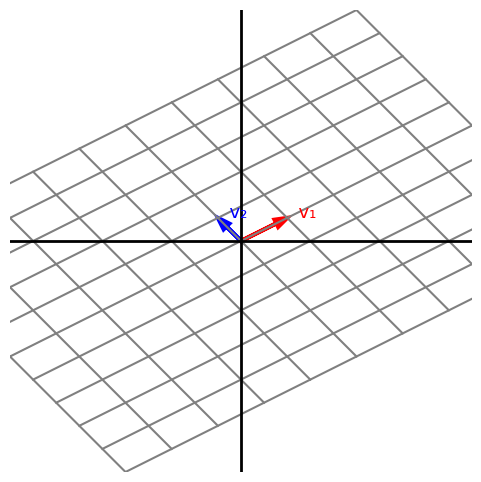

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Basis vectors
# -----------------------------
v1 = np.array([2,1])
v2 = np.array([-1,1])

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# -----------------------------
# Standard grid (visible but light)
# -----------------------------
#for i in range(-10,11):
#    ax.plot([-10,10],[i,i], color='#d0d0d0', linewidth=1)
#    ax.plot([i,i],[-10,10], color='#d0d0d0', linewidth=1)

# -----------------------------
# Basis grid
# -----------------------------
rng = range(-5,6)

for i in rng:
    pts = np.array([i*v2 + t*v1 for t in np.linspace(-5,5,200)])
    ax.plot(pts[:,0], pts[:,1], color='#808080', linewidth=1.5)

for j in rng:
    pts = np.array([j*v1 + t*v2 for t in np.linspace(-5,5,200)])
    ax.plot(pts[:,0], pts[:,1], color='#808080', linewidth=1.5)

# -----------------------------
# Standard axes
# -----------------------------
ax.axhline(0, color='black', linewidth=2)
ax.axvline(0, color='black', linewidth=2)

# -----------------------------
# Basis vectors
# -----------------------------
ax.arrow(
    0,0,v1[0],v1[1],
    head_width=0.35,
    length_includes_head=True,
    linewidth=3,
    color='red'
)

ax.arrow(
    0,0,v2[0],v2[1],
    head_width=0.35,
    length_includes_head=True,
    linewidth=3,
    color='blue'
)

# Labels
ax.text(v1[0],v1[1],"  v₁",color='red',fontsize=13)
ax.text(v2[0],v2[1],"  v₂",color='blue',fontsize=13)

# -----------------------------
# Formatting
# -----------------------------
ax.set_aspect('equal')
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# -----------------------------
# Save image
# -----------------------------
plt.savefig(
    r"C:\Users\RIB\Downloads\basis_grid.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

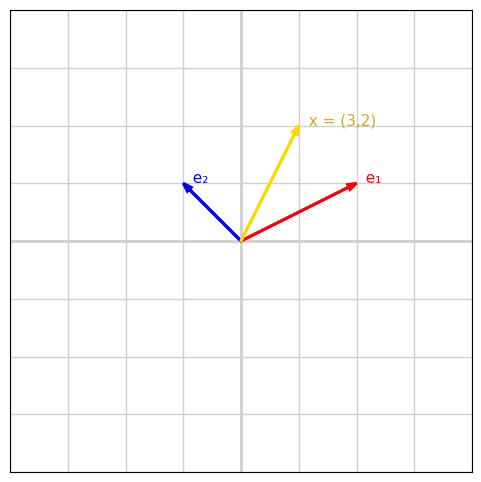

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Basis vectors
# -----------------------------
v1 = np.array([2,1])
v2 = np.array([-1,1])

# Vector to add
x = np.array([1,2])

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))

# Transparent background
# fig.patch.set_alpha(0)
# ax.patch.set_alpha(0)

# -----------------------------
# Standard grid
# -----------------------------
for i in range(-4,5):
    ax.plot([-4,4],[i,i], color='#d0d0d0', linewidth=1, zorder=0)
    ax.plot([i,i],[-4,4], color='#d0d0d0', linewidth=1, zorder=0)

# -----------------------------
# Standard axes
# -----------------------------
ax.axhline(0, color='#d0d0d0', linewidth=2, zorder=1)
ax.axvline(0, color='#d0d0d0', linewidth=2, zorder=1)

# -----------------------------
# Basis vectors
# -----------------------------
ax.arrow(
    0,0,v1[0],v1[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='red',
    zorder=5
)

ax.arrow(
    0,0,v2[0],v2[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='blue',
    zorder=5
)

# -----------------------------
# Vector x = (3,2)
# -----------------------------
ax.arrow(
    0,0,x[0],x[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='gold',
    zorder=6
)

# Labels
ax.text(v1[0],v1[1],"  e₁",color='red',fontsize=11, zorder=7)
ax.text(v2[0],v2[1],"  e₂",color='blue',fontsize=11, zorder=7)
ax.text(x[0],x[1],"  x = (3,2)",color='goldenrod',fontsize=11, zorder=7)

# -----------------------------
# Formatting
# -----------------------------
ax.set_aspect('equal')
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)

# -----------------------------
# Save image
# -----------------------------
plt.savefig(
    r"C:\Users\RIB\Downloads\basis_grid.png",
    dpi=600,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

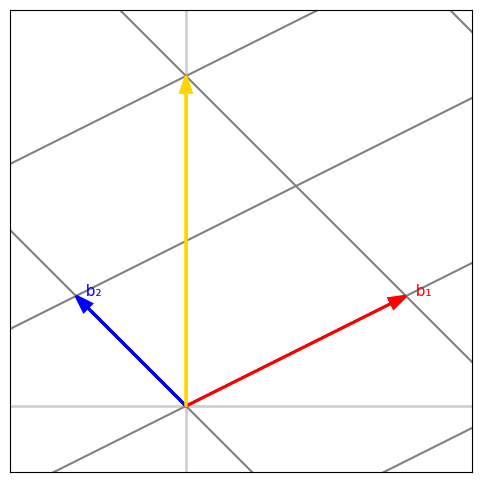

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Basis vectors
# -----------------------------
v1 = np.array([2,1])
v2 = np.array([-1,1])

# Vector to add
x = np.array([0,3])

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))

# Transparent background
# fig.patch.set_alpha(0)
# ax.patch.set_alpha(0)

# -----------------------------
# Standard grid
# -----------------------------
# for i in range(-2,9):
#     ax.plot([-2,8],[i,i], color='#d0d0d0', linewidth=1, zorder=0)
#     ax.plot([i,i],[-2,8], color='#d0d0d0', linewidth=1, zorder=0)

# -----------------------------
# Standard axes
# -----------------------------
ax.axhline(0, color='#d0d0d0', linewidth=2, zorder=1)
ax.axvline(0, color='#d0d0d0', linewidth=2, zorder=1)


# -----------------------------
# Basis grid
# -----------------------------
# Get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Make sure the grids cover the entire axis
t_vals = np.linspace(xlim[0]-v2[0]*12, xlim[1]+v2[0]*12, 400)
s_vals = np.linspace(ylim[0]-v1[1]*12, ylim[1]+v1[1]*12, 400)

# Choose a reasonable range so that grid lines fill the axis
# Calculate how far to go along each basis to fill the current plot
# Use a symmetric range wider than axis limits to be sure
n_grid = 20  # how many grid lines along each direction

# For each i (along v2), draw lines parallel to v1, sweeping enough to fill axis
for i in np.linspace(-n_grid, n_grid, 2*n_grid+1):
    pts = np.array([i*v2 + t*v1 for t in np.linspace(-12, 12, 400)])
    ax.plot(pts[:,0], pts[:,1], color='#808080', linewidth=1.5)

# For each j (along v1), draw lines parallel to v2
for j in np.linspace(-n_grid, n_grid, 2*n_grid+1):
    pts = np.array([j*v1 + t*v2 for t in np.linspace(-12, 12, 400)])
    ax.plot(pts[:,0], pts[:,1], color='#808080', linewidth=1.5)
# -----------------------------
# Basis vectors
# -----------------------------
ax.arrow(
    0,0,v1[0],v1[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='red',
    zorder=5
)

ax.arrow(
    0,0,v2[0],v2[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='blue',
    zorder=5
)

# -----------------------------
# Vector x = (3,2)
# -----------------------------
ax.arrow(
    0,0,x[0],x[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='gold',
    zorder=6
)

# Labels
ax.text(v1[0],v1[1],"  b₁",color='red',fontsize=11, zorder=7)
ax.text(v2[0],v2[1],"  b₂",color='blue',fontsize=11, zorder=7)
ax.text(x[0],x[1]," ", color='goldenrod',fontsize=11, zorder=7)

# -----------------------------
# Formatting: fit axes to vectors + margin
# -----------------------------
all_x = [0, v1[0], v2[0], x[0]]
all_y = [0, v1[1], v2[1], x[1]]
margin = 0.6
ax.set_aspect('equal')
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)

# -----------------------------
# Save image
# -----------------------------
plt.savefig(
    r"C:\Users\RIB\Downloads\basis_grid.png",
    dpi=600,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

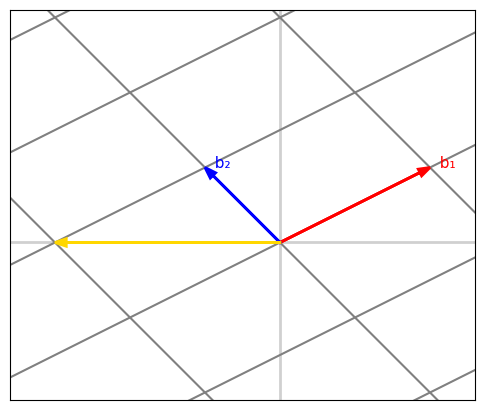

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Basis vectors
# -----------------------------
v1 = np.array([2,1])
v2 = np.array([-1,1])

# Vector to add
x = np.array([-3,0])

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))

# Transparent background
# fig.patch.set_alpha(0)
# ax.patch.set_alpha(0)

# -----------------------------
# Standard grid
# -----------------------------
# for i in range(-2,9):
#     ax.plot([-2,8],[i,i], color='#d0d0d0', linewidth=1, zorder=0)
#     ax.plot([i,i],[-2,8], color='#d0d0d0', linewidth=1, zorder=0)

# -----------------------------
# Standard axes
# -----------------------------
ax.axhline(0, color='#d0d0d0', linewidth=2, zorder=1)
ax.axvline(0, color='#d0d0d0', linewidth=2, zorder=1)


# -----------------------------
# Basis grid
# -----------------------------
# Get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Make sure the grids cover the entire axis
t_vals = np.linspace(xlim[0]-v2[0]*12, xlim[1]+v2[0]*12, 400)
s_vals = np.linspace(ylim[0]-v1[1]*12, ylim[1]+v1[1]*12, 400)

# Choose a reasonable range so that grid lines fill the axis
# Calculate how far to go along each basis to fill the current plot
# Use a symmetric range wider than axis limits to be sure
n_grid = 20  # how many grid lines along each direction

# For each i (along v2), draw lines parallel to v1, sweeping enough to fill axis
for i in np.linspace(-n_grid, n_grid, 2*n_grid+1):
    pts = np.array([i*v2 + t*v1 for t in np.linspace(-12, 12, 400)])
    ax.plot(pts[:,0], pts[:,1], color='#808080', linewidth=1.5)

# For each j (along v1), draw lines parallel to v2
for j in np.linspace(-n_grid, n_grid, 2*n_grid+1):
    pts = np.array([j*v1 + t*v2 for t in np.linspace(-12, 12, 400)])
    ax.plot(pts[:,0], pts[:,1], color='#808080', linewidth=1.5)
# -----------------------------
# Basis vectors
# -----------------------------
ax.arrow(
    0,0,v1[0],v1[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='red',
    zorder=5
)

ax.arrow(
    0,0,v2[0],v2[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='blue',
    zorder=5
)

# -----------------------------
# Vector x = (3,2)
# -----------------------------
ax.arrow(
    0,0,x[0],x[1],
    head_width=0.1,
    length_includes_head=True,
    linewidth=2,
    color='gold',
    zorder=6
)

# Labels
ax.text(v1[0],v1[1],"  b₁",color='red',fontsize=11, zorder=7)
ax.text(v2[0],v2[1],"  b₂",color='blue',fontsize=11, zorder=7)
ax.text(x[0],x[1], " ", color='goldenrod',fontsize=11, zorder=7)

# -----------------------------
# Formatting: same as cell 3, plus a bit more at top and bottom
# -----------------------------
all_x = [0, v1[0], v2[0], x[0]]
all_y = [0, v1[1], v2[1], x[1]]
margin = 0.6
extra_top_bottom = 1.5  # extra space above and below so plot is more square
ax.set_aspect('equal')
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin - extra_top_bottom, max(all_y) + margin + extra_top_bottom)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)

# -----------------------------
# Save image
# -----------------------------
plt.savefig(
    r"C:\Users\RIB\Downloads\basis_grid.png",
    dpi=600,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()